# Telecom Churn Dataset Feasibility Study

**Purpose:** This notebook checks whether the telecom usage dataset is suitable for a customer churn prediction project.

The main questions are:

1. Is the dataset clean and complete?
2. Does customer usage behaviour relate to churn?
3. Does feature extraction improve the relationship with churn?
4. Is there possible temporal leakage?
5. Which observation window should be used for the final model?

This notebook is only for dataset feasibility and professor review. It does not change the main project pipeline.

## 1. Data Dictionary

The dataset contains 90 days of customer usage behaviour across app traffic, voice usage, and package spending.

- `usage_app_youtube_daily`: YouTube traffic in MB.
- `usage_app_facebook_daily`: Facebook traffic in MB.
- `usage_app_tiktok_daily`: TikTok traffic in MB.
- `usage_app_whatsapp_daily`: WhatsApp traffic in MB.
- `usage_app_helakuru_daily`: Helakuru app traffic in MB.
- `usage_app_other`: Other app traffic in MB.
- `usage_voice_d2d_outgoing`: Outgoing call volume in minutes between same-operator users.
- `usage_voice_d2nd_outgoing`: Outgoing call volume in minutes from same operator to other operators.
- `usage_voice_d2d_incoming`: Incoming call volume in minutes between same-operator users.
- `usage_voice_nd2d_incoming`: Incoming call volume in minutes from other operators to same operator.
- `usage_pack_data`: Spend in LKR for data package purchases.
- `usage_pack_vas`: Spend in LKR for value-added services.

> Note: Use the exact `usage_type` names found in the dataset when running the code.

## 2. Load Data

The raw dataset is loaded from the local raw folder. The train and test label files are combined only for exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_DIR = r"C:\Users\kavin\Music\raw"

MAIN_PATH = RAW_DIR + r"\main.csv"
TRAIN_PATH = RAW_DIR + r"\train\train_cxid.csv"
TEST_PATH = RAW_DIR + r"\test\test_cxid.csv"

main = pd.read_csv(MAIN_PATH)
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

labels = pd.concat([train, test], ignore_index=True)

day_cols = [col for col in main.columns if col.startswith("Day_")]

print("Main shape:", main.shape)
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Labels shape:", labels.shape)
print("Number of day columns:", len(day_cols))
print("Unique customers:", main["customer_id"].nunique())
print("Usage types:", main["usage_type"].nunique())

main.head()

Main shape: (780060, 92)
Train shape: (52004, 2)
Test shape: (13001, 2)
Labels shape: (65005, 2)
Number of day columns: 90
Unique customers: 65005
Usage types: 12


,customer_id,usage_type,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,Day_10,Day_11,Day_12,Day_13,Day_14,Day_15,Day_16,Day_17,Day_18,Day_19,Day_20,Day_21,Day_22,Day_23,Day_24,Day_25,Day_26,Day_27,Day_28,Day_29,Day_30,Day_31,Day_32,Day_33,Day_34,Day_35,Day_36,Day_37,Day_38,Day_39,Day_40,Day_41,Day_42,Day_43,Day_44,Day_45,Day_46,Day_47,Day_48,Day_49,Day_50,Day_51,Day_52,Day_53,Day_54,Day_55,Day_56,Day_57,Day_58,Day_59,Day_60,Day_61,Day_62,Day_63,Day_64,Day_65,Day_66,Day_67,Day_68,Day_69,Day_70,Day_71,Day_72,Day_73,Day_74,Day_75,Day_76,Day_77,Day_78,Day_79,Day_80,Day_81,Day_82,Day_83,Day_84,Day_85,Day_86,Day_87,Day_88,Day_89,Day_90
0,e9126f469646506b8e82b4214d075bf72d9d324d357650...,usage_app_other,53.00,130.73,7.86,67.71,153.38,35.92,128.60,30.61,37.29,86.45,0.00,77.17,0.00,64.13,122.66,27.82,0.00,10.13,18.90,0.00,0.00,0.00,41.38,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
1,e9126f469646506b8e82b4214d075bf72d9d324d357650...,usage_app_youtube_daily,98.50,0.00,284.82,150.05,0.00,261.89,44.89,0.00,0.00,0.00,0.00,0.00,23.67,0.00,0.00,0.00,0.00,96.61,38.97,0.00,91.72,0.00,55.94,47.41,0.0,0.0,0.0,0.0,279.93,0.0,0.0,0.0,158.66,0.0,114.93,0.0,0.0,147.77,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,15.63,0.00,0.00,112.44,17.05,0.00,53.57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,50.28,0.0
2,e9126f469646506b8e82b4214d075bf72d9d324d357650...,usage_app_facebook_daily,79.42,72.61,72.15,82.82,61.06,57.91,55.59,56.46,50.07,47.65,34.87,43.82,30.76,23.70,20.36,21.03,25.00,27.88,18.49,24.19,11.80,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
3,e9126f469646506b8e82b4214d075bf72d9d324d357650...,usage_app_tiktok_daily,53.22,65.80,52.87,59.78,50.75,52.37,44.12,40.88,44.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.72,5.22,0.59,0.00,3.87,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
4,e9126f469646506b8e82b4214d075bf72d9d324d357650...,usage_app_whatsapp_daily,0.00,4.18,20.33,7.89,18.37,7.17,5.22,12.77,4.63,17.34,10.47,6.67,3.60,8.44,21.32,10.04,10.22,13.20,6.90,1.44,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,2.11,0.0,9.1,0.0,4.25,1.86,10.73,0.0,0.0,0.17,7.85,2.79,9.54,12.08,3.56,0.00,3.79,4.03,7.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.51,0.0,1.19,5.16,0.0,0.0,0.0,0.0,0.0,2.31,0.0,0.0,0.0,1.22,0.0


## 3. Basic Data Quality Check

This section checks missing values, duplicates, duplicate labels, and churn distribution.

In [2]:
print("Missing values in main:")
print(main.isnull().sum().sum())

print("\nDuplicate rows in main:")
print(main.duplicated().sum())

print("\nDuplicate customer IDs in labels:")
print(labels["customer_id"].duplicated().sum())

print("\nChurn distribution:")
print(labels["churn"].value_counts())

print("\nChurn percentage:")
print(labels["churn"].value_counts(normalize=True) * 100)

Missing values in main:
0

Duplicate rows in main:
0

Duplicate customer IDs in labels:
0

Churn distribution:
churn
0    50005
1    15000
Name: count, dtype: int64

Churn percentage:
churn
0    76.924852
1    23.075148
Name: proportion, dtype: float64


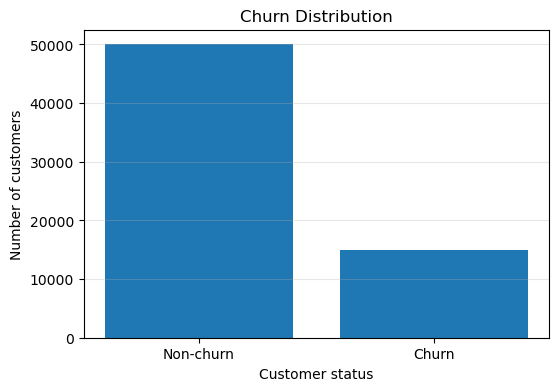

In [3]:
churn_counts = labels["churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-churn", "Churn"], churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Customer status")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Data Quality Finding

The dataset should be considered suitable for further analysis if there are no missing values, no duplicate rows, and no duplicate customer labels. A churn rate around 20–30% is usable because it represents a moderately imbalanced but realistic churn problem.

## 4. Usage Type Coverage Check

This section checks whether the dataset contains the expected usage categories and whether each customer has all usage types.

In [4]:
print("Usage type counts:")
print(main["usage_type"].value_counts())

print("\nNumber of usage types:")
print(main["usage_type"].nunique())

Usage type counts:
usage_type
usage_app_other              65005
usage_app_youtube_daily      65005
usage_app_facebook_daily     65005
usage_app_tiktok_daily       65005
usage_app_whatsapp_daily     65005
usage_app_helakuru_daily     65005
usage_voice_d2d_outgoing     65005
usage_voice_d2nd_outgoing    65005
usage_voice_d2d_incoming     65005
usage_voice_nd2d_incoming    65005
usage_pack_data              65005
usage_pack_vas               65005
Name: count, dtype: int64

Number of usage types:
12


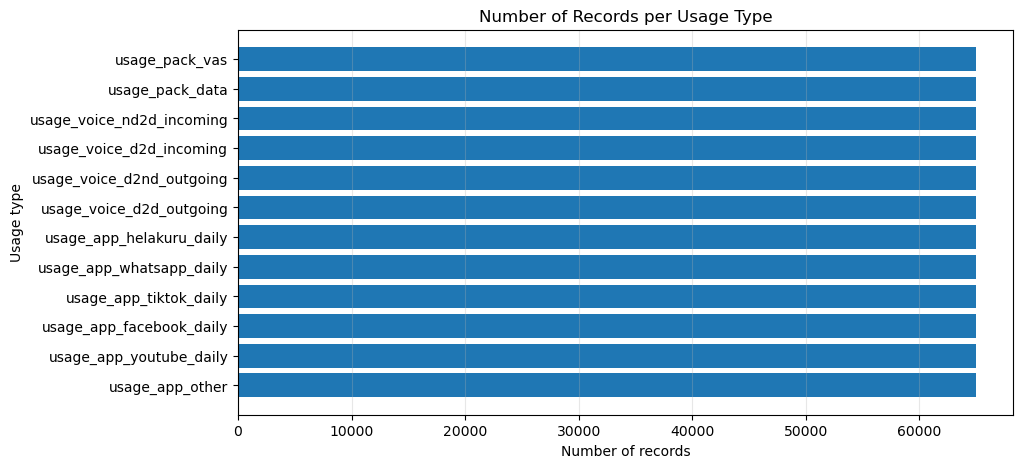

In [5]:
usage_counts = main["usage_type"].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(usage_counts.index, usage_counts.values)
plt.title("Number of Records per Usage Type")
plt.xlabel("Number of records")
plt.ylabel("Usage type")
plt.grid(axis="x", alpha=0.3)
plt.show()

count    65005.0
mean        12.0
std          0.0
min         12.0
25%         12.0
50%         12.0
75%         12.0
max         12.0
Name: usage_type, dtype: float64

Customers without all usage types:
0


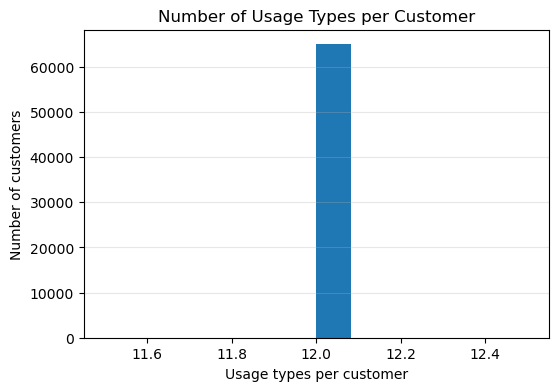

In [6]:
customer_usage_type_count = main.groupby("customer_id")["usage_type"].nunique()

print(customer_usage_type_count.describe())

print("\nCustomers without all usage types:")
print((customer_usage_type_count != main["usage_type"].nunique()).sum())

plt.figure(figsize=(6, 4))
plt.hist(customer_usage_type_count, bins=12)
plt.title("Number of Usage Types per Customer")
plt.xlabel("Usage types per customer")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Create Customer-Level Daily Usage Table

The raw dataset has multiple rows per customer, one row for each usage type. For customer-level churn analysis, the daily usage values are aggregated into one row per customer.

In [7]:
main_labeled = main.merge(labels, on="customer_id", how="left")

daily_total = main_labeled.groupby(["customer_id", "churn"])[day_cols].sum().reset_index()

print("Daily total shape:", daily_total.shape)
print("Missing churn labels:", daily_total["churn"].isnull().sum())
print("\nChurn distribution after aggregation:")
print(daily_total["churn"].value_counts())

daily_total.head()

Daily total shape: (65005, 92)
Missing churn labels: 0

Churn distribution after aggregation:
churn
0    50005
1    15000
Name: count, dtype: int64


,customer_id,churn,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,Day_10,Day_11,Day_12,Day_13,Day_14,Day_15,Day_16,Day_17,Day_18,Day_19,Day_20,Day_21,Day_22,Day_23,Day_24,Day_25,Day_26,Day_27,Day_28,Day_29,Day_30,Day_31,Day_32,Day_33,Day_34,Day_35,Day_36,Day_37,Day_38,Day_39,Day_40,Day_41,Day_42,Day_43,Day_44,Day_45,Day_46,Day_47,Day_48,Day_49,Day_50,Day_51,Day_52,Day_53,Day_54,Day_55,Day_56,Day_57,Day_58,Day_59,Day_60,Day_61,Day_62,Day_63,Day_64,Day_65,Day_66,Day_67,Day_68,Day_69,Day_70,Day_71,Day_72,Day_73,Day_74,Day_75,Day_76,Day_77,Day_78,Day_79,Day_80,Day_81,Day_82,Day_83,Day_84,Day_85,Day_86,Day_87,Day_88,Day_89,Day_90
0,0000f727854b50bb95c054b39c1fe5c92e5ebcfa4bcb5d...,0,571.75,866.04,1023.04,899.85,1243.72,618.86,1254.51,1527.92,610.90,624.32,1168.21,636.58,453.02,876.58,480.24,599.89,533.82,817.28,688.13,865.31,424.84,595.81,798.04,640.21,654.72,460.43,374.94,728.14,511.29,894.18,141.50,522.09,487.27,197.83,750.79,154.56,1289.77,1620.75,1031.53,568.50,1004.50,1004.41,1055.75,834.00,857.43,896.89,1360.00,826.77,264.08,1301.62,284.46,1007.99,659.27,756.36,773.03,310.42,971.60,1262.32,1188.82,1450.10,739.10,814.51,892.15,804.21,1547.75,1460.25,1122.51,1319.74,1166.90,768.19,1267.56,1823.35,1501.18,1247.50,1877.44,1738.95,1399.68,1351.73,873.65,1414.30,996.42,791.61,1027.83,925.30,1585.33,1557.09,1472.03,1923.08,1200.73,707.74
1,0001702d0abcdbeeb23f7c434aa6858030f365caf1464a...,1,663.91,674.13,692.89,589.74,528.71,1011.27,660.66,700.76,714.45,890.91,615.89,809.82,527.51,539.54,402.62,255.32,861.95,419.49,513.42,57.26,117.06,114.71,169.63,56.02,50.87,67.76,69.42,169.51,301.31,172.51,328.61,188.50,302.60,153.21,215.11,214.72,525.11,348.34,454.28,361.76,350.73,542.27,374.97,517.05,515.94,428.52,402.68,464.97,458.45,319.16,352.78,352.95,320.29,291.41,455.54,306.90,207.91,203.42,220.02,222.72,303.95,333.54,293.75,277.61,263.87,272.72,277.80,285.20,279.56,289.24,282.95,289.54,423.37,439.38,435.92,587.53,435.49,474.54,540.94,436.57,476.72,555.27,530.26,508.36,833.63,468.30,474.29,541.29,714.22,560.95
2,0001ae52a920c36edc7ab364ea58a58ca725f0ad44c02b...,1,597.68,1005.06,972.84,744.51,1004.07,528.44,628.41,849.26,1287.10,772.90,542.00,1026.46,683.74,1274.39,909.39,579.78,993.62,317.77,389.93,474.92,220.43,352.94,655.56,484.37,461.54,357.53,350.79,249.30,87.43,262.45,873.61,1078.92,339.84,577.06,978.70,577.74,599.12,515.78,721.60,1131.54,1065.02,1041.55,771.80,838.08,828.30,662.75,527.50,828.05,548.47,697.22,722.08,686.16,302.46,636.79,1220.96,668.00,1198.79,838.37,368.29,358.36,1206.44,571.44,893.60,646.04,731.67,732.83,748.66,817.42,1054.14,1434.51,1250.85,1201.81,1187.83,1611.57,1028.02,1576.89,851.60,798.42,870.67,1565.47,888.31,1184.21,802.65,1095.52,678.62,700.94,1070.73,697.85,849.23,541.87
3,000205e54ddf8bc7512490895ce397647faaedc114f411...,0,626.76,1131.79,1085.28,567.39,468.95,507.59,685.02,571.65,361.97,565.19,737.03,431.08,676.84,642.88,205.57,613.68,459.28,252.24,276.04,460.48,284.21,573.24,650.82,115.50,444.94,862.38,263.31,872.88,694.45,373.07,454.95,601.29,1474.20,741.97,670.13,512.86,2215.09,2095.68,649.98,752.69,1107.06,817.37,1114.39,781.99,1355.30,723.89,938.21,673.96,1532.62,1201.43,736.91,837.19,1311.80,604.96,1288.71,967.16,1708.90,1412.62,858.61,840.70,1468.49,1494.06,945.77,1247.93,1385.33,782.12,969.56,1030.56,752.03,585.50,1003.36,978.21,1185.59,1613.11,1627.66,1397.49,2394.92,1168.69,1638.72,1203.43,1107.16,2189.27,1562.89,1361.57,1625.62,2057.25,2263.78,1477.02,1971.20,1930.62
4,0002511664bff302e40b19ed6872ad4390ac59901e55e2...,0,663.85,638.90,430.57,469.55,446.92,296.98,378.07,293.29,361.05,500.99,425.30,328.54,538.96,210.26,281.79,136.85,572.16,346.09,505.18,594.29,513.51,716.17,603.82,457.51,542.72,104.05,283.71,508.05,875.98,386.80,381.02,516.79,517.37,336.72,490.78,322.06,636.64,619.02,536.80,616.23,437.08,315.47,252.26,451.87,234.97,487.70,374.36,433.44,778.70,884.59,791.51,768.21,788.73,415.98,675.30,788.87,700.25,733.04,752.88,449.45,383.69,372.10,290.04,708.13,1011.60,868.94,963.36,902.62

## 6. Univariate Analysis

This section studies the overall distribution of customer usage without considering churn first.

In [8]:
daily_total["total_90_usage"] = daily_total[day_cols].sum(axis=1)
daily_total["avg_daily_usage"] = daily_total[day_cols].mean(axis=1)
daily_total["zero_days_90"] = (daily_total[day_cols] == 0).sum(axis=1)

daily_total[["total_90_usage", "avg_daily_usage", "zero_days_90"]].describe()

,total_90_usage,avg_daily_usage,zero_days_90
count,65005.000000,65005.000000,65005.000000
mean,61779.751267,686.441681,0.456380
std,23685.556769,263.172853,1.877697
min,7338.130000,81.534778,0.000000
25%,46366.230000,515.180333,0.000000
50%,65732.850000,730.365000,0.000000
75%,78983.560000,877.595111,0.000000
max,143802.470000,1597.805222,48.000000


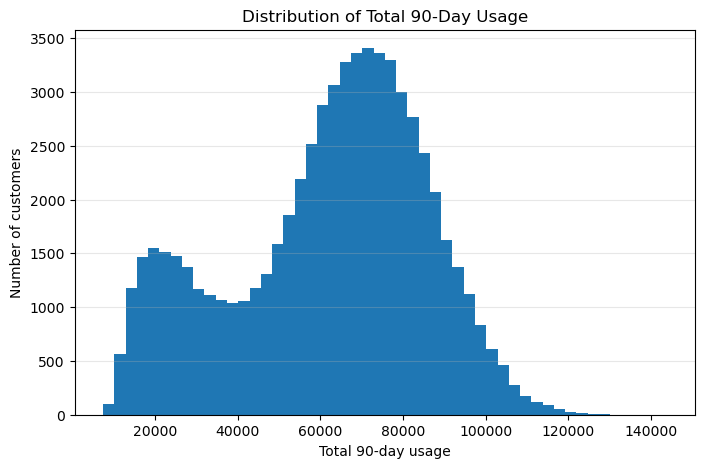

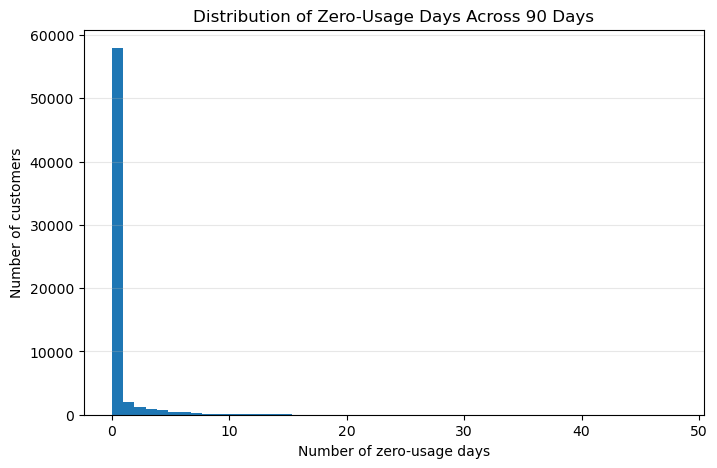

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(daily_total["total_90_usage"], bins=50)
plt.title("Distribution of Total 90-Day Usage")
plt.xlabel("Total 90-day usage")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(daily_total["zero_days_90"], bins=50)
plt.title("Distribution of Zero-Usage Days Across 90 Days")
plt.xlabel("Number of zero-usage days")
plt.ylabel("Number of customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Univariate Finding

Most customers are active during the 90-day observation period. The median zero-usage days should be checked carefully. If the median is close to zero, the dataset is not simply full of inactive customers.

## 7. Bivariate Analysis: Churn vs Usage

This section compares churned and non-churned customers.

In [10]:
daily_total.groupby("churn")[["total_90_usage", "avg_daily_usage", "zero_days_90"]].mean()

,total_90_usage,avg_daily_usage,zero_days_90
churn,,,
0,71974.738413,799.719316,0.002380
1,27793.062449,308.811805,1.969867


<Figure size 700x500 with 0 Axes>

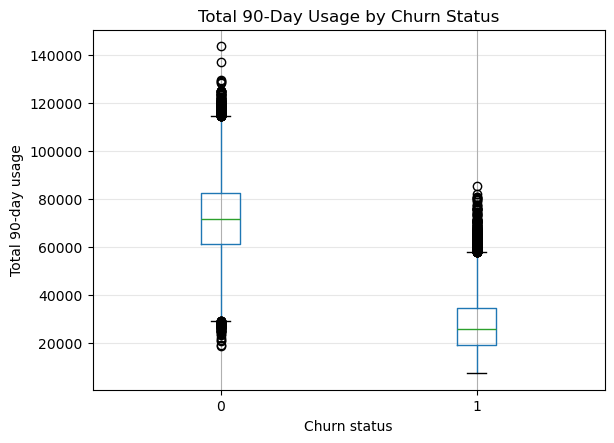

<Figure size 700x500 with 0 Axes>

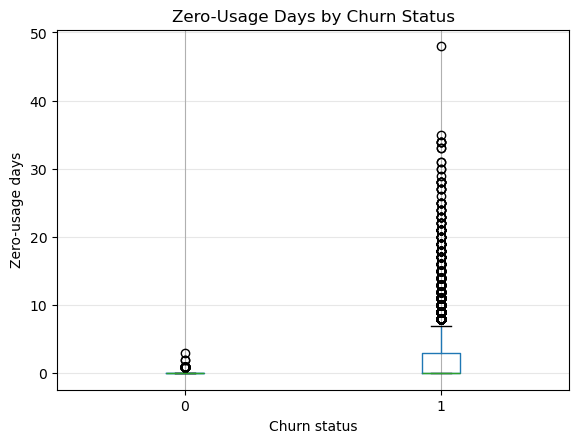

In [11]:
plt.figure(figsize=(7, 5))
daily_total.boxplot(column="total_90_usage", by="churn")
plt.title("Total 90-Day Usage by Churn Status")
plt.suptitle("")
plt.xlabel("Churn status")
plt.ylabel("Total 90-day usage")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
daily_total.boxplot(column="zero_days_90", by="churn")
plt.title("Zero-Usage Days by Churn Status")
plt.suptitle("")
plt.xlabel("Churn status")
plt.ylabel("Zero-usage days")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Bivariate Finding

If churned customers show much lower usage than non-churned customers, the dataset contains a clear behavioural signal. However, this must be followed by temporal analysis to check whether the signal represents early churn behaviour or late-stage inactivity.

## 8. Temporal Usage Pattern Analysis

This section checks whether the churn signal develops gradually over time.

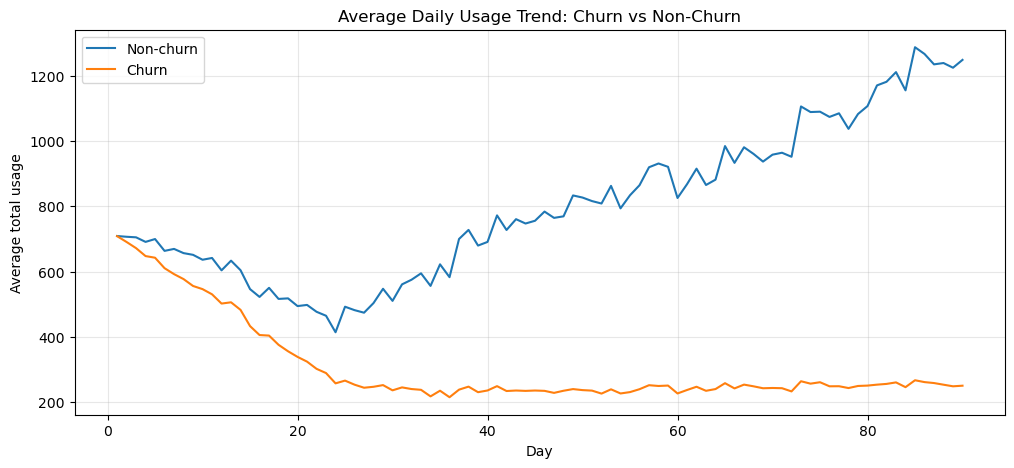

In [12]:
avg_usage_by_churn = daily_total.groupby("churn")[day_cols].mean().T
avg_usage_by_churn.index = range(1, 91)

plt.figure(figsize=(12, 5))
plt.plot(avg_usage_by_churn.index, avg_usage_by_churn[0], label="Non-churn")
plt.plot(avg_usage_by_churn.index, avg_usage_by_churn[1], label="Churn")
plt.title("Average Daily Usage Trend: Churn vs Non-Churn")
plt.xlabel("Day")
plt.ylabel("Average total usage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

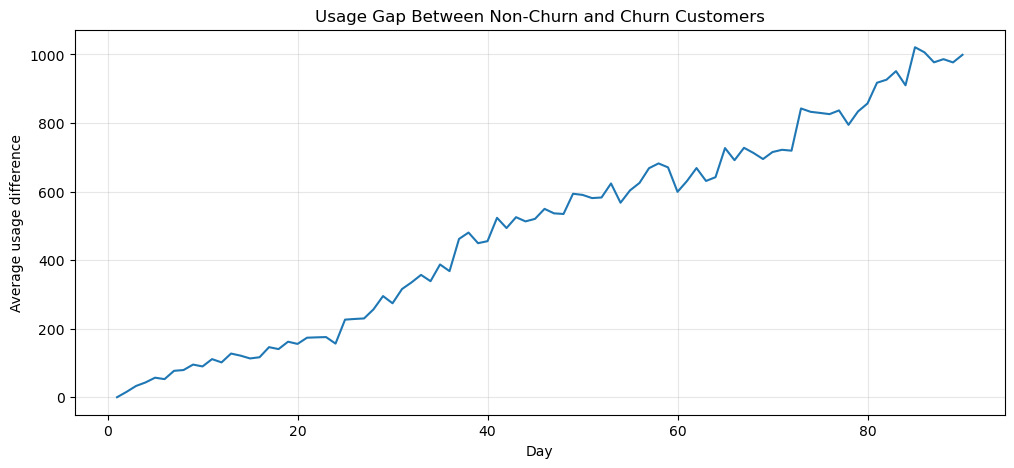

In [13]:
daily_gap = avg_usage_by_churn[0] - avg_usage_by_churn[1]

plt.figure(figsize=(12, 5))
plt.plot(daily_gap.index, daily_gap.values)
plt.title("Usage Gap Between Non-Churn and Churn Customers")
plt.xlabel("Day")
plt.ylabel("Average usage difference")
plt.grid(True, alpha=0.3)
plt.show()

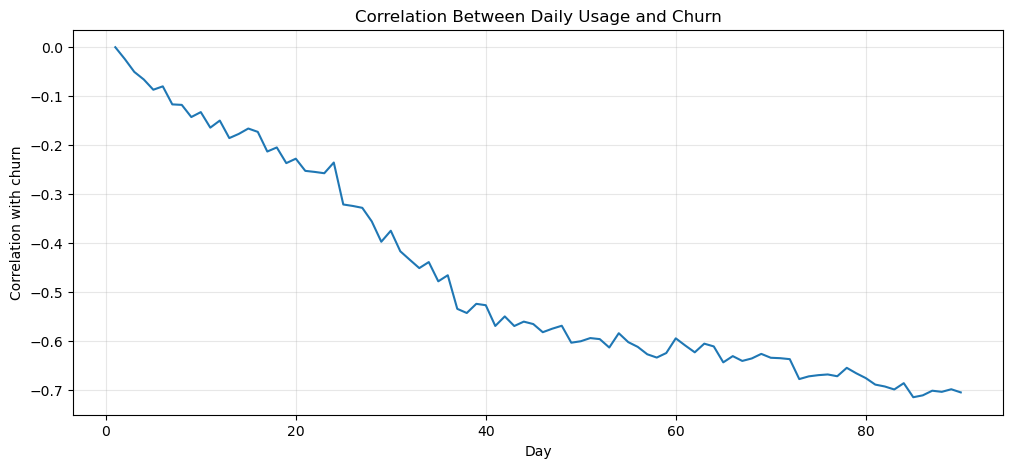

,day,correlation
0,1,-0.000462
1,2,-0.024556
2,3,-0.050854
3,4,-0.066333
4,5,-0.087234


In [14]:
corrs = []

for col in day_cols:
    corr = daily_total[col].corr(daily_total["churn"])
    corrs.append(corr)

corr_by_day_df = pd.DataFrame({
    "day": range(1, 91),
    "correlation": corrs
})

plt.figure(figsize=(12, 5))
plt.plot(corr_by_day_df["day"], corr_by_day_df["correlation"])
plt.title("Correlation Between Daily Usage and Churn")
plt.xlabel("Day")
plt.ylabel("Correlation with churn")
plt.grid(True, alpha=0.3)
plt.show()

corr_by_day_df.head()

### Temporal Finding

A gradual increase in the churn relationship over time is better than a sudden change only near the end. A gradual pattern suggests declining engagement. A sudden end-period pattern would create stronger leakage concerns.

## 9. Leakage Risk Investigation

The main concern is whether the model is predicting churn early or simply detecting customers who have already stopped using the service.

In [15]:
def last_active_day(row):
    for i in range(90, 0, -1):
        if row[f"Day_{i}"] > 0:
            return i
    return 0

daily_total["last_active_day"] = daily_total.apply(last_active_day, axis=1)

daily_total.groupby("churn")[["zero_days_90", "last_active_day"]].describe()

zero_days_90                                                \
             count      mean       std  min  25%  50%  75%   max   
churn                                                              
0          50005.0  0.002380  0.050736  0.0  0.0  0.0  0.0   3.0   
1          15000.0  1.969867  3.506229  0.0  0.0  0.0  3.0  48.0   

      last_active_day                                                     
                count       mean       std   min   25%   50%   75%   max  
churn                                                                     
0             50005.0  90.000000  0.000000  90.0  90.0  90.0  90.0  90.0  
1             15000.0  89.878133  0.731927  48.0  90.0  90.0  90.0  90.0

<Figure size 700x500 with 0 Axes>

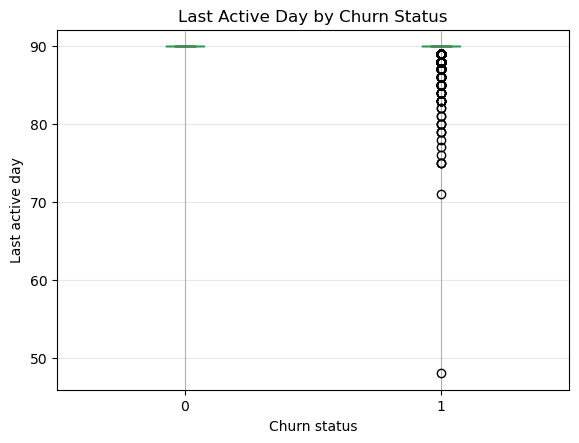

In [16]:
plt.figure(figsize=(7, 5))
daily_total.boxplot(column="last_active_day", by="churn")
plt.title("Last Active Day by Churn Status")
plt.suptitle("")
plt.xlabel("Churn status")
plt.ylabel("Last active day")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [17]:
daily_total["zero_days_1_30"] = (daily_total[[f"Day_{i}" for i in range(1, 31)]] == 0).sum(axis=1)
daily_total["zero_days_31_60"] = (daily_total[[f"Day_{i}" for i in range(31, 61)]] == 0).sum(axis=1)
daily_total["zero_days_61_90"] = (daily_total[[f"Day_{i}" for i in range(61, 91)]] == 0).sum(axis=1)

daily_total.groupby("churn")[["zero_days_1_30", "zero_days_31_60", "zero_days_61_90"]].mean()

,zero_days_1_30,zero_days_31_60,zero_days_61_90
churn,,,
0,0.002180,0.00016,0.00004
1,0.044867,0.60540,1.31960


### Leakage Finding

If churned customers still have a high median last active day, the churn signal is not explained only by complete inactivity. Since the exact churn date is unavailable, temporal leakage cannot be fully ruled out. To reduce this risk, the final model should use an early observation window.

## 10. Usage Totals by 30-Day Windows

This section compares usage across the first, middle, and last 30 days.

In [18]:
daily_total["usage_1_30"] = daily_total[[f"Day_{i}" for i in range(1, 31)]].sum(axis=1)
daily_total["usage_31_60"] = daily_total[[f"Day_{i}" for i in range(31, 61)]].sum(axis=1)
daily_total["usage_61_90"] = daily_total[[f"Day_{i}" for i in range(61, 91)]].sum(axis=1)

window_usage_summary = daily_total.groupby("churn")[["usage_1_30", "usage_31_60", "usage_61_90"]].mean()
window_usage_summary

,usage_1_30,usage_31_60,usage_61_90
churn,,,
0,17274.883997,22604.852801,32095.001615
1,13238.527285,7068.349761,7486.185404


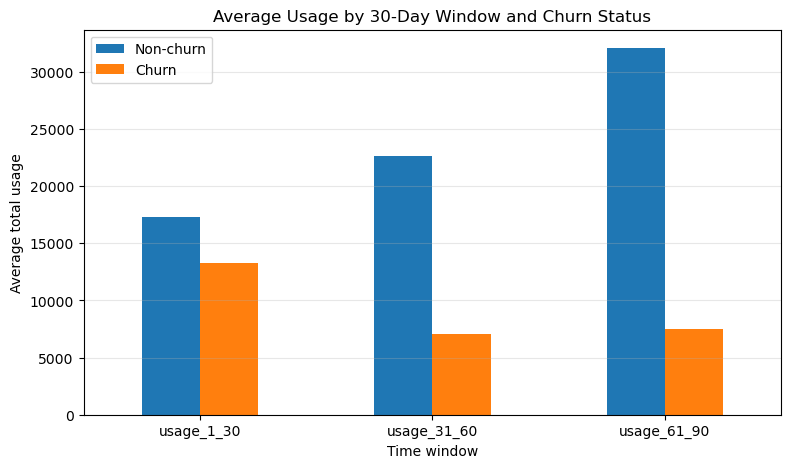

In [19]:
window_usage_summary.T.plot(kind="bar", figsize=(9, 5))
plt.title("Average Usage by 30-Day Window and Churn Status")
plt.xlabel("Time window")
plt.ylabel("Average total usage")
plt.xticks(rotation=0)
plt.legend(["Non-churn", "Churn"])
plt.grid(axis="y", alpha=0.3)
plt.show()

## 11. Usage Type Analysis

This section checks whether individual services such as data packs, VAS, app usage, and voice usage have a relationship with churn.

In [20]:
usage_type_summary = main_labeled.groupby(["usage_type", "churn"])[day_cols].sum().sum(axis=1).reset_index()
usage_type_summary.columns = ["usage_type", "churn", "total_usage"]

usage_type_avg = usage_type_summary.copy()
usage_type_avg["customer_count"] = usage_type_avg["churn"].map(labels["churn"].value_counts())
usage_type_avg["avg_usage_per_customer"] = usage_type_avg["total_usage"] / usage_type_avg["customer_count"]

pivot_usage_type = usage_type_avg.pivot(
    index="usage_type",
    columns="churn",
    values="avg_usage_per_customer"
)

pivot_usage_type.columns = ["Non-churn", "Churn"]
pivot_usage_type

,Non-churn,Churn
usage_type,,
usage_app_facebook_daily,9336.247724,3613.841397
usage_app_helakuru_daily,1239.370855,478.965155
usage_app_other,12407.005264,4793.998579
usage_app_tiktok_daily,8061.318746,3139.754131
usage_app_whatsapp_daily,1236.986945,488.916235
usage_app_youtube_daily,14868.088305,5704.778053
usage_pack_data,12436.398819,4776.873641
usage_pack_vas,2480.894501,963.546238
usage_voice_d2d_incoming,2488.388934,950.051591


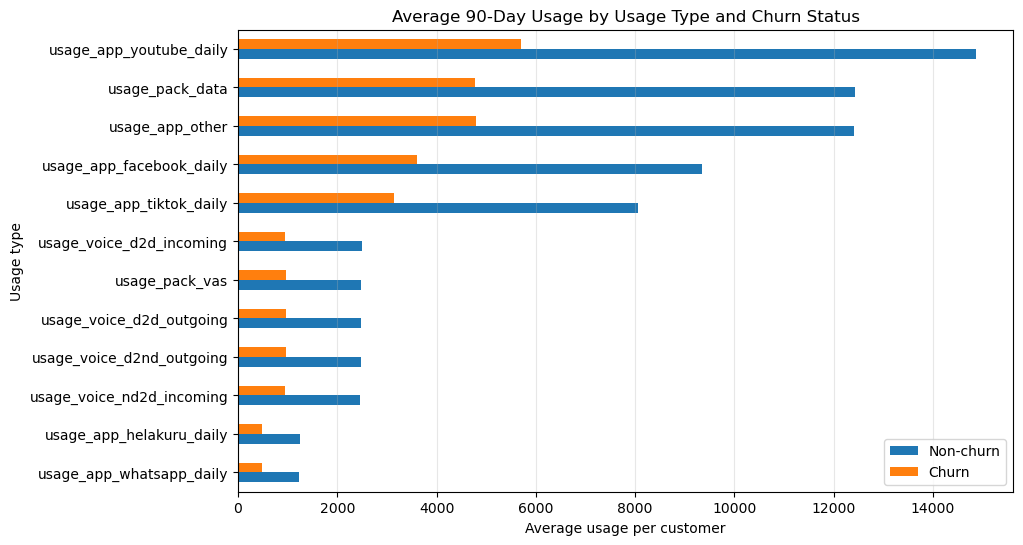

In [21]:
pivot_usage_type.sort_values("Non-churn").plot(kind="barh", figsize=(10, 6))
plt.title("Average 90-Day Usage by Usage Type and Churn Status")
plt.xlabel("Average usage per customer")
plt.ylabel("Usage type")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [22]:
usage_type_features = (
    main_labeled
    .groupby(["customer_id", "churn", "usage_type"])[day_cols]
    .sum()
    .sum(axis=1)
    .unstack()
    .reset_index()
)

usage_type_corr = (
    usage_type_features
    .drop(columns=["customer_id"])
    .corr()["churn"]
    .drop("churn")
    .sort_values()
)

usage_type_corr

usage_type
usage_voice_d2d_incoming    -0.432284
usage_pack_data             -0.430164
usage_app_other             -0.429547
usage_app_facebook_daily    -0.429343
usage_app_youtube_daily     -0.429279
usage_voice_nd2d_incoming   -0.428015
usage_app_helakuru_daily    -0.427401
usage_voice_d2d_outgoing    -0.427250
usage_pack_vas              -0.426721
usage_voice_d2nd_outgoing   -0.426083
usage_app_tiktok_daily      -0.425244
usage_app_whatsapp_daily    -0.420575
Name: churn, dtype: float64

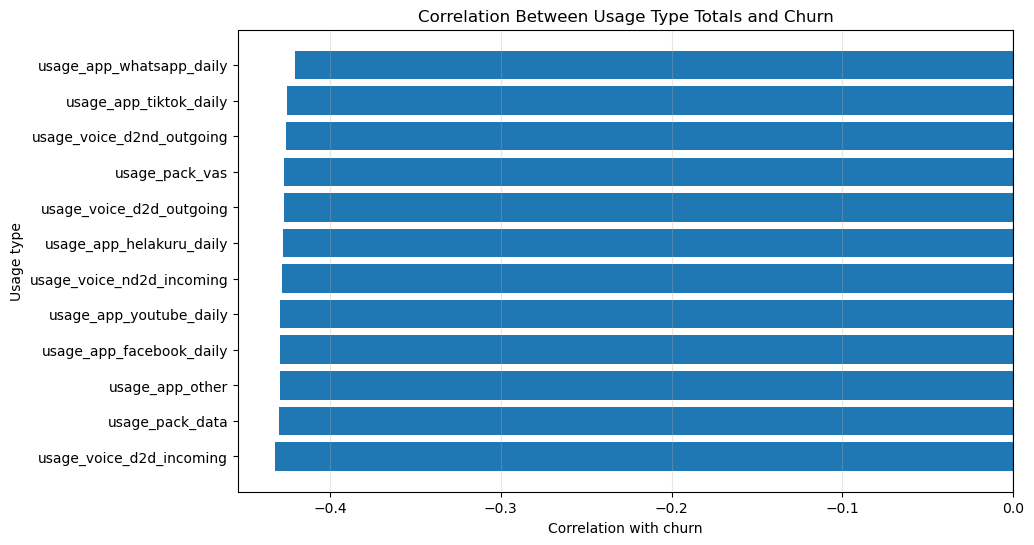

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(usage_type_corr.index, usage_type_corr.values)
plt.title("Correlation Between Usage Type Totals and Churn")
plt.xlabel("Correlation with churn")
plt.ylabel("Usage type")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.3)
plt.show()

### Usage Type Finding

A negative correlation means lower usage or spending in that usage type is associated with higher churn. If all usage types show similar negative correlation, this suggests churn is linked to broad customer disengagement, not just one specific service.

## 12. Correlation Between Usage Types

This checks whether usage types are highly correlated with each other. Low correlation between usage types is not a problem. It can mean the columns capture different behaviours.

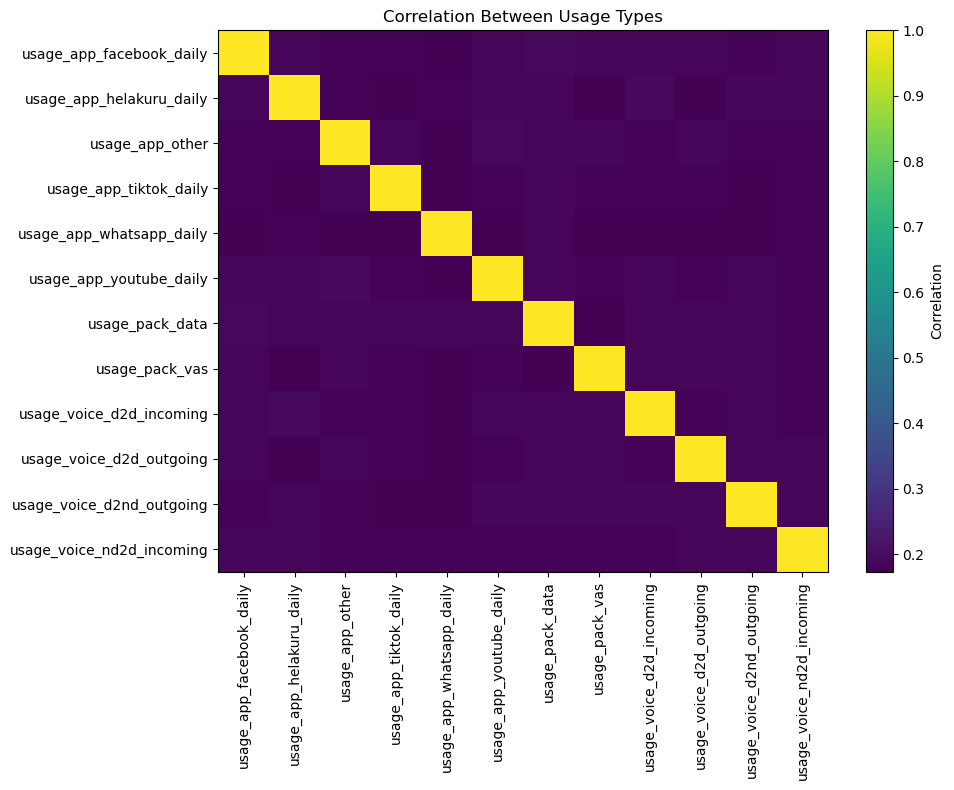

In [24]:
usage_type_only = usage_type_features.drop(columns=["customer_id", "churn"])
usage_type_corr_matrix = usage_type_only.corr()

plt.figure(figsize=(10, 8))
plt.imshow(usage_type_corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(usage_type_corr_matrix.columns)), usage_type_corr_matrix.columns, rotation=90)
plt.yticks(range(len(usage_type_corr_matrix.index)), usage_type_corr_matrix.index)
plt.title("Correlation Between Usage Types")
plt.tight_layout()
plt.show()

### Usage-Type Correlation Note

The important question is not whether YouTube, Facebook, VAS, voice, and data-pack usage are highly correlated with each other. The key question is whether these behaviours, and the features extracted from them, are related to churn. Low correlation between usage types can be acceptable because the variables may provide complementary information.

## 13. Feature Extraction

This section creates behavioural features from the raw daily usage columns. These features summarize usage level, inactivity, usage change, usage ratios, and intensity.

In [25]:
# Window totals
daily_total["usage_1_7"] = daily_total[[f"Day_{i}" for i in range(1, 8)]].sum(axis=1)
daily_total["usage_1_14"] = daily_total[[f"Day_{i}" for i in range(1, 15)]].sum(axis=1)
daily_total["usage_1_30"] = daily_total[[f"Day_{i}" for i in range(1, 31)]].sum(axis=1)
daily_total["usage_31_60"] = daily_total[[f"Day_{i}" for i in range(31, 61)]].sum(axis=1)
daily_total["usage_61_90"] = daily_total[[f"Day_{i}" for i in range(61, 91)]].sum(axis=1)

# Zero days by window
daily_total["zero_days_1_30"] = (daily_total[[f"Day_{i}" for i in range(1, 31)]] == 0).sum(axis=1)
daily_total["zero_days_31_60"] = (daily_total[[f"Day_{i}" for i in range(31, 61)]] == 0).sum(axis=1)
daily_total["zero_days_61_90"] = (daily_total[[f"Day_{i}" for i in range(61, 91)]] == 0).sum(axis=1)

# Activity features
daily_total["active_days"] = (daily_total[day_cols] > 0).sum(axis=1)
daily_total["usage_std"] = daily_total[day_cols].std(axis=1)

# Behaviour change features
daily_total["usage_trend"] = daily_total["usage_61_90"] - daily_total["usage_1_30"]
daily_total["usage_change_pct"] = (
    (daily_total["usage_61_90"] - daily_total["usage_1_30"])
    / (daily_total["usage_1_30"] + 1)
)

daily_total["usage_drop_1_30_to_31_60"] = daily_total["usage_31_60"] - daily_total["usage_1_30"]
daily_total["usage_drop_1_30_to_61_90"] = daily_total["usage_61_90"] - daily_total["usage_1_30"]

daily_total["recent_usage_ratio"] = daily_total["usage_61_90"] / (daily_total["usage_1_30"] + 1)
daily_total["mid_usage_ratio"] = daily_total["usage_31_60"] / (daily_total["usage_1_30"] + 1)

# Activity intensity
daily_total["max_daily_usage"] = daily_total[day_cols].max(axis=1)
daily_total["min_daily_usage"] = daily_total[day_cols].min(axis=1)
daily_total["median_daily_usage"] = daily_total[day_cols].median(axis=1)
daily_total["usage_range"] = daily_total["max_daily_usage"] - daily_total["min_daily_usage"]

print("Feature extraction completed.")

Feature extraction completed.


## 14. Correlation Between Extracted Features and Churn

This section directly answers the professor's question: after feature extraction, do the extracted features show correlation with churn?

In [26]:
feature_cols = [
    "total_90_usage",
    "avg_daily_usage",
    "usage_1_7",
    "usage_1_14",
    "usage_1_30",
    "usage_31_60",
    "usage_61_90",
    "zero_days_90",
    "zero_days_1_30",
    "zero_days_31_60",
    "zero_days_61_90",
    "active_days",
    "usage_std",
    "usage_trend",
    "usage_change_pct",
    "usage_drop_1_30_to_31_60",
    "usage_drop_1_30_to_61_90",
    "recent_usage_ratio",
    "mid_usage_ratio",
    "max_daily_usage",
    "median_daily_usage",
    "usage_range",
    "last_active_day"
]

corr_df = (
    daily_total[feature_cols + ["churn"]]
    .corr()["churn"]
    .drop("churn")
    .sort_values()
)

corr_df

recent_usage_ratio         -0.812761
usage_change_pct           -0.812757
median_daily_usage         -0.806904
mid_usage_ratio            -0.806486
usage_61_90                -0.800085
usage_drop_1_30_to_61_90   -0.797333
usage_trend                -0.797333
usage_31_60                -0.790594
avg_daily_usage            -0.785900
total_90_usage             -0.785900
usage_drop_1_30_to_31_60   -0.772482
max_daily_usage            -0.535012
usage_std                  -0.510460
usage_range                -0.476445
usage_1_30                 -0.453170
active_days                -0.441464
usage_1_14                 -0.244569
last_active_day            -0.144505
usage_1_7                  -0.125404
zero_days_1_30              0.143955
zero_days_31_60             0.373064
zero_days_61_90             0.402614
zero_days_90                0.441464
Name: churn, dtype: float64

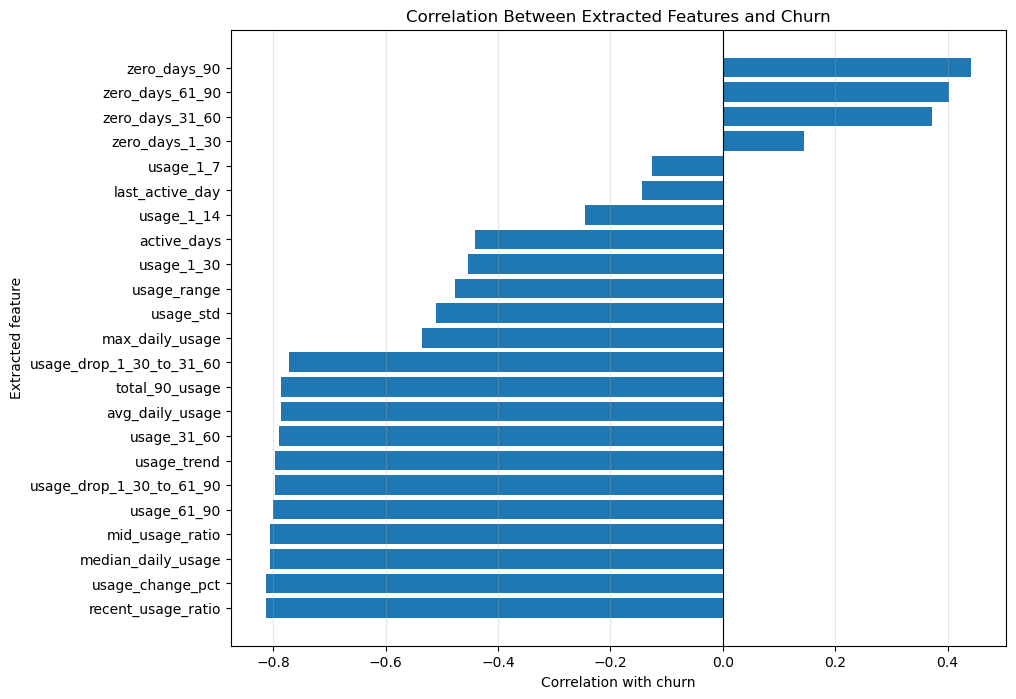

In [27]:
corr_plot_df = corr_df.reset_index()
corr_plot_df.columns = ["feature", "correlation"]

plt.figure(figsize=(10, 8))
plt.barh(corr_plot_df["feature"], corr_plot_df["correlation"])
plt.title("Correlation Between Extracted Features and Churn")
plt.xlabel("Correlation with churn")
plt.ylabel("Extracted feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.3)
plt.show()

### Feature Correlation Finding

The extracted features should show stronger relationships with churn than raw daily values. Features related to recent usage ratio, usage change, median usage, usage trend, and zero-usage days are especially important because they describe behavioural change rather than isolated daily values.

## 15. Raw vs Engineered Feature Correlation Comparison

This section compares raw usage-type features with engineered behavioural features.

In [28]:
raw_feature_corr = usage_type_corr.abs().mean()
engineered_feature_corr = corr_df.abs().mean()

improvement_pct = ((engineered_feature_corr - raw_feature_corr) / raw_feature_corr) * 100

print("Average absolute correlation (raw usage-type features):", raw_feature_corr)
print("Average absolute correlation (engineered features):", engineered_feature_corr)
print("Percentage improvement after feature extraction:", improvement_pct)

Average absolute correlation (raw usage-type features): 0.4276589751501912
Average absolute correlation (engineered features): 0.5678548103630466
Percentage improvement after feature extraction: 32.78215666200377


### Raw vs Engineered Feature Finding

If the average absolute correlation is higher after feature extraction, this shows that feature engineering improved the relationship between customer behaviour and churn. This supports the use of extracted behavioural features in the final churn model.

## 16. Churn Rate by Usage Segment

This section checks whether customers with lower usage have higher churn rates.

In [29]:
daily_total["usage_segment"] = pd.qcut(
    daily_total["total_90_usage"],
    q=4,
    labels=["Low usage", "Medium-low usage", "Medium-high usage", "High usage"]
)

segment_churn = daily_total.groupby("usage_segment", observed=False)["churn"].mean() * 100
segment_churn

usage_segment
Low usage            85.841743
Medium-low usage      5.919636
Medium-high usage     0.479970
High usage            0.055381
Name: churn, dtype: float64

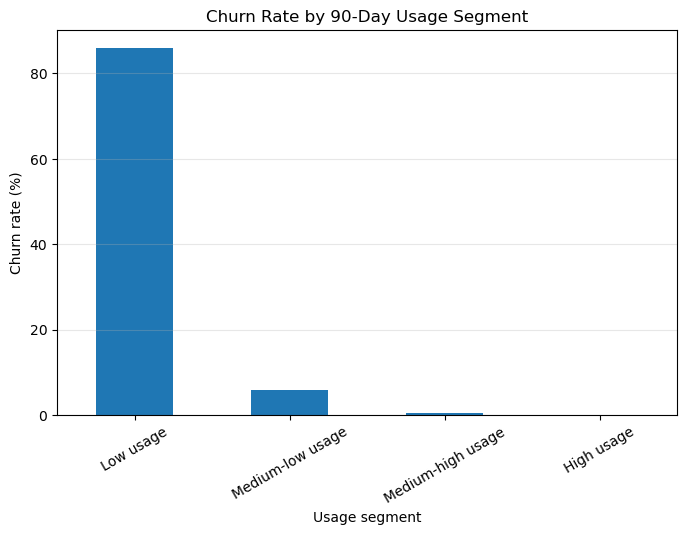

In [30]:
segment_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by 90-Day Usage Segment")
plt.xlabel("Usage segment")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 17. Early Usage Segment Analysis

This section checks whether churn signal is already visible using only the first 30 days.

In [31]:
daily_total["early_usage_segment"] = pd.qcut(
    daily_total["usage_1_30"],
    q=4,
    labels=["Low early usage", "Medium-low early usage", "Medium-high early usage", "High early usage"]
)

early_segment_churn = daily_total.groupby("early_usage_segment", observed=False)["churn"].mean() * 100
early_segment_churn

early_usage_segment
Low early usage            56.983756
Medium-low early usage     18.245031
Medium-high early usage    11.020860
High early usage            6.048859
Name: churn, dtype: float64

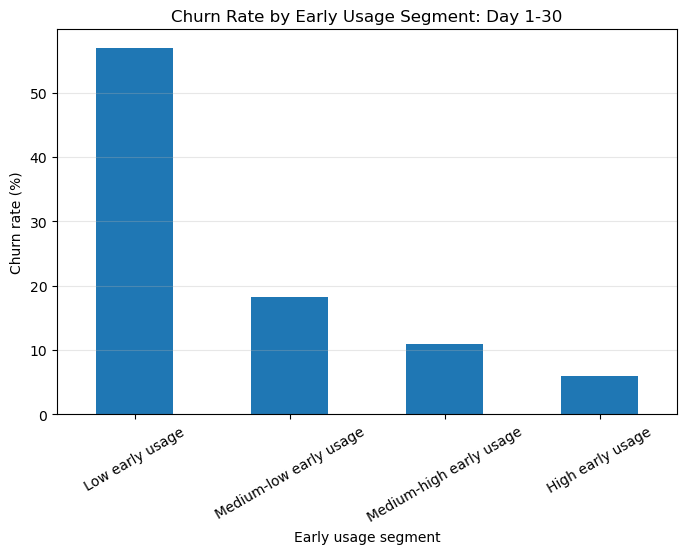

In [32]:
early_segment_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Early Usage Segment: Day 1-30")
plt.xlabel("Early usage segment")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Early Signal Finding

If the low early-usage group has a much higher churn rate than the high early-usage group, this supports using the first 30 days as an early-warning observation window.

## 18. Observation Window Comparison

This section compares different observation windows to justify why Day 1–30 is selected for the final model.

In [33]:
windows = [7, 14, 30, 45, 60, 90]
window_results = []

for w in windows:
    cols = [f"Day_{i}" for i in range(1, w + 1)]
    total_col = f"usage_1_{w}"
    segment_col = f"segment_1_{w}"

    daily_total[total_col] = daily_total[cols].sum(axis=1)

    corr = daily_total[total_col].corr(daily_total["churn"])

    daily_total[segment_col] = pd.qcut(
        daily_total[total_col],
        q=4,
        labels=["Low", "Medium-low", "Medium-high", "High"],
        duplicates="drop"
    )

    churn_rates = daily_total.groupby(segment_col, observed=False)["churn"].mean() * 100

    window_results.append({
        "window_days": w,
        "correlation_with_churn": corr,
        "low_usage_churn_rate": churn_rates.loc["Low"],
        "high_usage_churn_rate": churn_rates.loc["High"],
        "risk_gap": churn_rates.loc["Low"] - churn_rates.loc["High"]
    })

window_results_df = pd.DataFrame(window_results)
window_results_df

,window_days,correlation_with_churn,low_usage_churn_rate,high_usage_churn_rate,risk_gap
0,7,-0.125404,34.746493,18.220417,16.526076
1,14,-0.244569,42.425548,13.340717,29.084830
2,30,-0.453170,56.983756,6.048859,50.934897
3,45,-0.653984,73.861679,1.310689,72.550990
4,60,-0.734860,80.974649,0.338441,80.636209
5,90,-0.785900,85.841743,0.055381,85.786361


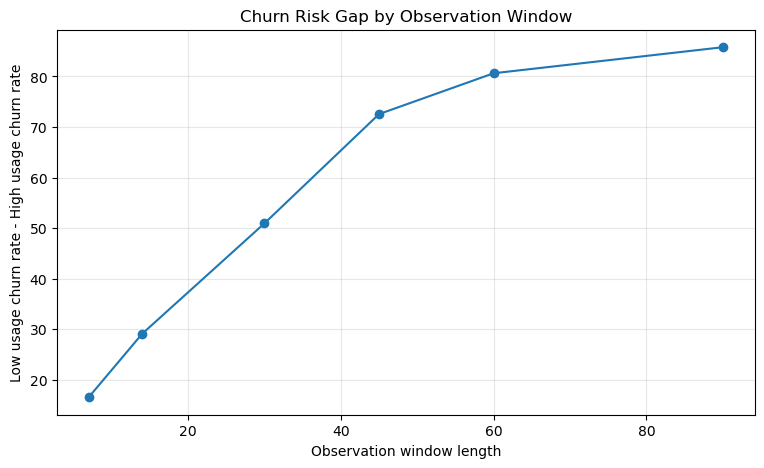

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(window_results_df["window_days"], window_results_df["risk_gap"], marker="o")
plt.title("Churn Risk Gap by Observation Window")
plt.xlabel("Observation window length")
plt.ylabel("Low usage churn rate - High usage churn rate")
plt.grid(True, alpha=0.3)
plt.show()

### Window Selection Finding

A 7-day or 14-day window may be too short because short-term usage can fluctuate. A 45-day, 60-day, or 90-day window gives stronger churn signals, but it also increases temporal leakage risk because churn may already be obvious.

The 30-day window gives a practical balance. It contains a strong churn signal while still supporting early retention action.

## 19. Final Dataset Feasibility Assessment

Based on the exploratory analysis, the dataset is feasible for a telecom churn prediction project.

Key evidence:

1. The dataset is clean and complete.
2. The dataset contains 65,005 customers, 12 usage types, and 90 days of usage history.
3. The churn rate is usable for modelling.
4. Churned customers show lower usage and clear usage decline.
5. Most churned customers are not completely inactive for the whole period.
6. Usage type totals have a relationship with churn.
7. Extracted behavioural features show stronger correlation with churn than raw usage-type features.
8. The first 30 days already contain a meaningful churn signal.

Therefore, the dataset can be used for the project, but the final model should use an early observation window to reduce leakage risk.

## 20. Limitation

The dataset does not include the exact churn date. Because of this, temporal leakage cannot be fully ruled out.

To reduce this risk, the final churn model should use only early usage behaviour, mainly Day 1–30, as the observation window. Longer windows such as Day 1–60 and Day 1–90 should be used only as comparison experiments or limitations, not as the main final model.

## 21. Final Modelling Decision

The final project should be framed as an **early churn warning model**.

Recommended modelling setup:

- **Main model:** Use Day 1–30 usage behaviour.
- **Optional comparison:** Compare with Day 1–7, Day 1–14, Day 1–45, Day 1–60, and Day 1–90.
- **Avoid using Day 1–90 as the main model** because it gives the strongest signal but also has the highest leakage risk.

Final statement:

> The dataset is feasible because feature extraction reveals meaningful churn-related behavioural patterns. A 30-day observation window is selected because it provides a strong early signal while reducing the risk of detecting churn only after inactivity has already become obvious.